In [88]:
import sys
sys.path.append("src")

In [130]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "text.usetex": False,          # set True only if LaTeX is installed
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,

    "figure.figsize": (7.2, 5.0),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "axes.linewidth": 1.1,

    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    "legend.fontsize": 11,
    "legend.frameon": False,

    "lines.linewidth": 2.0,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "grid.alpha": 0.25,
})


def get_cmap_colors(n, cmap_name="inferno", vmin=0.15, vmax=0.88):
    cmap = plt.get_cmap(cmap_name)
    vals = np.linspace(vmin, vmax, n)
    return [cmap(v) for v in vals]

In [89]:
import numpy as np
import torch

# Choose device
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float64

print("Using device:", device)

import grid_log
import importlib
import cosmology
import collision_log_linearized
#from kinematics import energy, cosphi, mandelstam_s_t, sqrt_one_minus_cosphi2

from cosmology import VariableGCosmology
#from grid_log import make_log_q_grid, interp_nearest_log_uniform_vec

#from grid import grid_edges_from_centers, bin_widths_from_centers, from grid import, interp_linear_uniform

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

Using device: cuda


In [90]:
from grid_log import make_log_q_grid as mygrid

#qmin = 10**(-3)
#qmax = 10**2
#N = 100
#a =1

#q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)
#p = q / a

In [91]:

cosmo = VariableGCosmology()

T_of_a = cosmo.T_of_a
H_of_a = cosmo.H_of_a

In [92]:
T_of_a(30)

array(5.34968416)

In [93]:
H_of_a(10.)

np.float64(3.278831909879231e-16)

# Checking the kernel of the collision operator F

In [94]:
from functools import partial
import solver
import func2

from solver import integrate_rk4_a, integrate_rk4_a_trajectory, integrate_heun_adaptive_a_trajectory, run_hybrid_FI_then_adaptive_self

In [95]:
from cBE_solver import solve_condensate_N_loga_quad, solve_free_in_loga_with_abundance, radiation_dominance_ratio


a0 = 1.0
a1_cbe = 5e4
#m_h2=1.

Gamma_X = 1e-21
nX_init = 0.02
N_init = a0**3 * nX_init

a_grid_raw, u_grid_raw, build_condensate = solve_condensate_N_loga_quad(
    H_of_a=cosmo.H_of_a,
    N_init=N_init,
    ai=a0,
    af=a1_cbe,
    n_eval=4000,
    zero_rel=1e-14,
)

NX_grid_raw, NX_of_a, nX_of_a = build_condensate(Gamma_X)

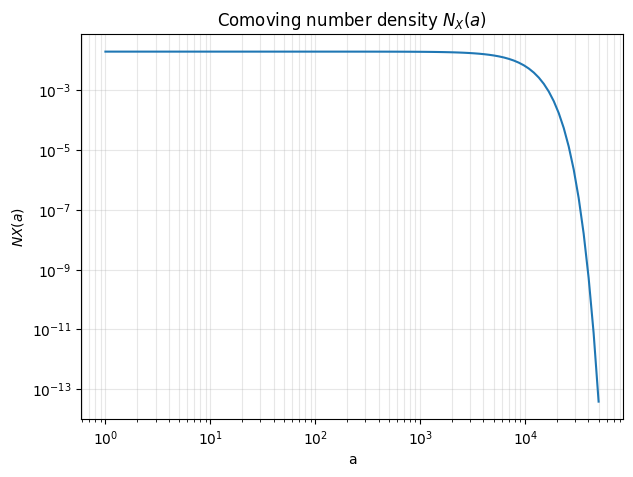

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# a-grid for plotting
a_grid = np.logspace(np.log10(a0), np.log10(a1_cbe), 100)

NX_grid = np.array([NX_of_a(a) for a in a_grid])


# Plot Ns(a)
plt.figure(figsize=(7, 5))
plt.plot(a_grid, NX_grid)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("a")
plt.ylabel(r"$NX(a)$")
plt.title(r"Comoving number density $N_X(a)$")
plt.grid(True, which="both", alpha=0.3)
plt.show()


In [97]:
m_chi = 0.5         # DM mass in GeV, example
m_h = 125.0          # Higgs mass in GeV
mX = 1.2

a1_cbe = 3*10**4


v_h = 246.0
lam_portal = 1.08e-11    # example

sol, Ns, Ts, Y_sol, Y_obs, ratio = solve_free_in_loga_with_abundance(
    cosmo=cosmo,
    ms=m_chi,
    lhs=lam_portal,
    xi_inf=1e-4,
    ai=a0,
    af=a1_cbe,
    mh=m_h,
    v=246.0,
    nX_of_a=nX_of_a,
    Gamma_X=Gamma_X,
    mX=mX,
    m_other=m_chi,
    multiplicity_X=2.0,
    method="Radau",
    rtol=1e-6,
    atol=1e-9,
    max_step_u=0.001,
)


print("Y_solver =", Y_sol)
print("Y_obs    =", Y_obs)
print("ratio    =", ratio)

Y_solver = 8.807291116884451e-10
Y_obs    = 8.743582702003838e-10
ratio    = 1.007286305517075


In [98]:
from collision_log_linearized import init_mb_target_from_cbe
sol_cbe = init_mb_target_from_cbe(
    cosmo=cosmo,
    ms=m_chi,
    lhs=lam_portal,
    xi_inf=5e-5,
    ai=a0,
    af=a1_cbe,
    mh=m_h,
    v=246.0,
    nX_of_a=nX_of_a,
    Gamma_X=Gamma_X,
    mX=mX,
    m_other=m_chi,
    multiplicity_X=2.0,
)

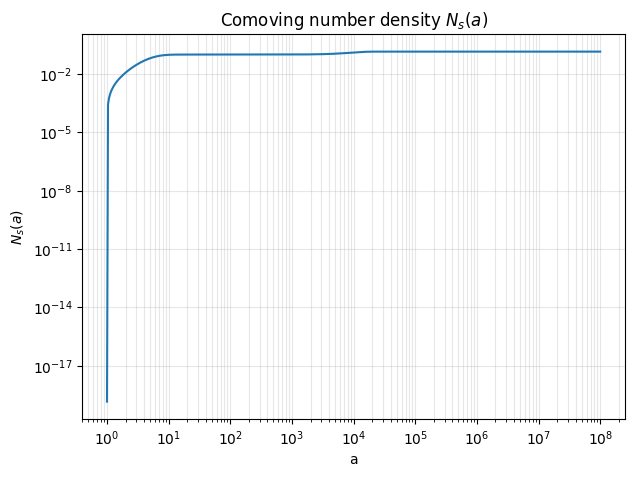

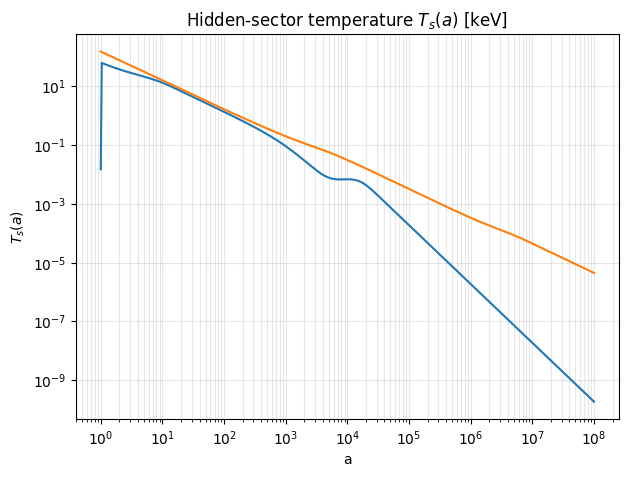

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# a-grid for plotting
a_grid = np.logspace(np.log10(a0), np.log10(10**8), 500)

Ns_grid = np.array([Ns(a) for a in a_grid])
Ts_grid = np.array([Ts(a) for a in a_grid])

Tsm_grid = np.array([T_of_a(a) for a in a_grid])


# Plot Ns(a)
plt.figure(figsize=(7, 5))
plt.plot(a_grid, Ns_grid)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("a")
plt.ylabel(r"$N_s(a)$")
plt.title(r"Comoving number density $N_s(a)$")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Plot Ts(a)
plt.figure(figsize=(7, 5))
plt.plot(a_grid, Ts_grid)
plt.plot(a_grid, Tsm_grid)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("a")
plt.ylabel(r"$T_s(a)$")
plt.title(r"Hidden-sector temperature $T_s(a)$ [keV]")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [13]:
# Choose grid and params (keep modest while testing)
from collision_log_linearized import rhs_df_da_torch_logq_FI

N = 180
qmin = 10**(-1)
qmax = 10**6
#a =1

q, logq0, dlogq, log_space = mygrid(qmin, qmax, N)

q = q.to(device=device, dtype=dtype)
logq0 = torch.as_tensor(logq0, device=device, dtype=dtype)
dlogq = torch.as_tensor(dlogq, device=device, dtype=dtype)

In [15]:
from datetime import datetime
from pathlib import Path

import gc


from solver import run_hybrid_FI_then_adaptive_self

# --------------------------------------------------
# global setup
# --------------------------------------------------

batch_size = 36

a0 = 1.0
af = 6e4

m_h = 125.0
g_trilinear = lam_portal * v_h

Ng = 12
gamma_over_H_on = 0.12

# Hybrid/RK4 controls
n_windows = 400
rk4_steps_per_window = 1
rk4_store_every_steps = 20

# Heun controls
heun_store_every_accepted = 20
heun_print_every_accepted = 30

# Four self-coupling cases
lam_self_values = [5e-6,1e-5, 5e-5, 1e-4, 5e-4]

# Initial condition
f0_base = torch.zeros_like(q, device=device, dtype=dtype)

all_trajs = {}

# --------------------------------------------------
# run scan
# --------------------------------------------------

for lam_self in lam_self_values:

    print("=" * 80)
    print(f"Starting run with lam_self = {lam_self:.1e}")
    print("=" * 80)

    # Fresh f0 for each run
    f0 = f0_base.clone()

    run_name = (
        f"hybrid_saved_"
        f"N{q.numel()}_"
        f"lamself{lam_self:.1e}_"
        f"Ng{Ng}_"
        f"batch{batch_size}_"
        f"nw{n_windows}_"
        f"rk4spw{rk4_steps_per_window}_"
        f"af{af:.1e}"
    )

    metadata = {
        "run_name": run_name,
        "a0": float(a0),
        "af": float(af),
        "N_grid": int(q.numel()),
        "qmin": float(q[0].detach().cpu()),
        "qmax": float(q[-1].detach().cpu()),
        "batch_size": int(batch_size),
        "Ng": int(Ng),
        "m_chi": float(m_chi),
        "m_h": float(m_h),
        "mX": float(mX),
        "m_other2": float(m_chi),
        "lam_portal": float(lam_portal),
        "v_h": float(v_h),
        "g_trilinear": float(g_trilinear),
        "lam_self": float(lam_self),
        "multiplicity2": 2.0,
        "gchi": 1.0,
        "pref_FI": 1.0,
        "mode": "FI_RK4_until_Gamma_over_H_threshold_then_FULL_HEUN",
        "gamma_over_H_on": float(gamma_over_H_on),
        "n_windows": int(n_windows),
        "rk4_steps_per_window": int(rk4_steps_per_window),
        "rk4_store_every_steps": int(rk4_store_every_steps),
        "heun_store_every_accepted": int(heun_store_every_accepted),
        "heun_print_every_accepted": int(heun_print_every_accepted),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }

    traj = run_hybrid_FI_then_adaptive_self(
        f0=f0,
        a0=a0,
        af=af,
        q=q,
        logq0=logq0,
        dlogq=dlogq,
        log_space=log_space,
        m_chi=m_chi,
        H_of_a=H_of_a,
        T_of_a=T_of_a,
        m_h=m_h,
        g_trilinear=g_trilinear,
        nX_of_a=nX_of_a,
        Gamma_X=Gamma_X,
        mX=mX,
        lam_self=lam_self,

        batch_size=batch_size,
        Ng=Ng,

        # Hybrid control
        n_windows=n_windows,
        gamma_over_H_on=gamma_over_H_on,
        rk4_steps_per_window=rk4_steps_per_window,
        rk4_store_every_steps=rk4_store_every_steps,

        # Adaptive Heun settings once self turns on
        heun_du_init=1e-3,
        heun_du_min=1e-5,
        heun_du_max=0.1,
        heun_rtol=1e-2,
        heun_atol=1e-12,
        heun_safety=0.95,

        # Store/print Heun snapshots
        heun_store_every_accepted=heun_store_every_accepted,
        heun_print_every_accepted=heun_print_every_accepted,

        clip_negative=True,
        clip_tol=0.0,

        # Saving
        out_path_pt="trajectory.pt",
        out_path_dat="trajectory.dat",
        results_dir="results",
        run_name=run_name,
        metadata=metadata,
    )

    # Keep in memory too, useful for immediate comparisons
    all_trajs[lam_self] = traj

    # --------------------------------------------------
    # summary
    # --------------------------------------------------

    a_snap = traj["a"]
    f_snap = traj["f"]
    f_final = traj["f_final"]

    modes = traj["mode_hist"]
    first_full = next((i for i, m in enumerate(modes) if m == "FULL_HEUN"), None)

    print("-" * 80)
    print("Run:", run_name)
    print("Saved to:", f"results/{run_name}/")
    print("a_snap:", a_snap.shape)
    print("f_snap:", f_snap.shape)
    print("finite after run:", torch.isfinite(f_final).all().item())
    print("min/max after run:", f_final.min().item(), f_final.max().item())
    print("settings:", traj["settings"])

    if first_full is not None:
        print("Self-scattering switched on at saved snapshot index:", first_full)
        print("a_switch from trajectory ≈", float(a_snap[first_full].detach().cpu()))

        if traj["a_switch"] is not None:
            print("a_switch from solver ≈", float(traj["a_switch"].detach().cpu()))
    else:
        print("Self-scattering never crossed the Gamma/H threshold.")

    print("Number of saved snapshots:", len(a_snap))
    print("Saved files:")
    print(f"  results/{run_name}/trajectory.pt")
    print(f"  results/{run_name}/trajectory.dat")
    print(f"  results/{run_name}/metadata.json")
    print("-" * 80)

    # after printing the run summary
     
    del traj
    del a_snap
    del f_snap
    del f_final
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

Starting run with lam_self = 5.0e-06
[hybrid] window 1/400 a=1.027887e+00 mode=FI_RK4 Gamma/H=0.000e+00 finite=True
[hybrid] window 11/400 a=1.353316e+00 mode=FI_RK4 Gamma/H=2.823e-07 finite=True
[hybrid] window 21/400 a=1.781775e+00 mode=FI_RK4 Gamma/H=7.096e-07 finite=True
[hybrid] window 31/400 a=2.345885e+00 mode=FI_RK4 Gamma/H=1.205e-06 finite=True
[hybrid] window 41/400 a=3.088592e+00 mode=FI_RK4 Gamma/H=1.587e-06 finite=True
[hybrid] window 51/400 a=4.066439e+00 mode=FI_RK4 Gamma/H=1.668e-06 finite=True
[hybrid] window 61/400 a=5.353873e+00 mode=FI_RK4 Gamma/H=1.488e-06 finite=True
[hybrid] window 71/400 a=7.048908e+00 mode=FI_RK4 Gamma/H=1.995e-06 finite=True
[hybrid] window 81/400 a=9.280591e+00 mode=FI_RK4 Gamma/H=3.468e-06 finite=True
[hybrid] window 91/400 a=1.221882e+01 mode=FI_RK4 Gamma/H=5.134e-06 finite=True
[hybrid] window 101/400 a=1.608730e+01 mode=FI_RK4 Gamma/H=6.836e-06 finite=True
[hybrid] window 111/400 a=2.118054e+01 mode=FI_RK4 Gamma/H=8.924e-06 finite=True
[h

In [ ]:
import torch
from datetime import datetime

from solver import run_hybrid_FI_then_adaptive_self

# --------------------------------------------------
# setup
# --------------------------------------------------

batch_size = 36

a0 = 1.0
af = e4

m_h = 125.0
g_trilinear = lam_portal * v_h
lam_self = 5e-4

Ng = 12
gamma_over_H_on = 0.5

# Hybrid/RK4 controls
n_windows = 300
rk4_steps_per_window = 1

# This stores every 20 internal RK4 steps.
# With rk4_steps_per_window=2, this means each RK4 window stores only its endpoint.
# If you want exactly one saved point every 20 RK4 substeps, use rk4_steps_per_window=20.
rk4_store_every_steps = 20

# Heun controls
heun_store_every_accepted = 20

f0 = torch.zeros_like(q, device=device, dtype=dtype)

run_name = (
    f"hybrid_saved_"
    f"N{q.numel()}_"
    f"lamself{lam_self:.1e}_"
    f"Ng{Ng}_"
    f"batch{batch_size}_"
    f"nw{n_windows}_"
    f"rk4spw{rk4_steps_per_window}_"
    f"af{af:.1e}"
)

metadata = {
    "run_name": run_name,
    "a0": float(a0),
    "af": float(af),
    "N_grid": int(q.numel()),
    "qmin": float(q[0].detach().cpu()),
    "qmax": float(q[-1].detach().cpu()),
    "batch_size": int(batch_size),
    "Ng": int(Ng),
    "m_chi": float(m_chi),
    "m_h": float(m_h),
    "mX": float(mX),
    "m_other2": float(m_chi),
    "lam_portal": float(lam_portal),
    "v_h": float(v_h),
    "g_trilinear": float(g_trilinear),
    "lam_self": float(lam_self),
    "multiplicity2": 2.0,
    "gchi": 1.0,
    "pref_FI": 1.0,
    "mode": "FI_RK4_until_Gamma_over_H_threshold_then_FULL_HEUN",
    "gamma_over_H_on": float(gamma_over_H_on),
    "n_windows": int(n_windows),
    "rk4_steps_per_window": int(rk4_steps_per_window),
    "rk4_store_every_steps": int(rk4_store_every_steps),
    "heun_store_every_accepted": int(heun_store_every_accepted),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

# --------------------------------------------------
# hybrid evolution
# --------------------------------------------------

traj = run_hybrid_FI_then_adaptive_self(
    f0=f0,
    a0=a0,
    af=af,
    q=q,
    logq0=logq0,
    dlogq=dlogq,
    log_space=log_space,
    m_chi=m_chi,
    H_of_a=H_of_a,
    T_of_a=T_of_a,
    m_h=m_h,
    g_trilinear=g_trilinear,
    nX_of_a=nX_of_a,
    Gamma_X=Gamma_X,
    mX=mX,
    lam_self=lam_self,

    batch_size=batch_size,
    Ng=Ng,

    # Hybrid control
    n_windows=n_windows,
    gamma_over_H_on=gamma_over_H_on,
    rk4_steps_per_window=rk4_steps_per_window,
    rk4_store_every_steps=rk4_store_every_steps,

    # Adaptive Heun settings once self turns on
    heun_du_init=1e-3,
    heun_du_min=1e-5,
    heun_du_max=0.1,
    heun_rtol=1e-2,
    heun_atol=1e-12,
    heun_safety=0.95,

    # Store Heun snapshots every 20 accepted adaptive steps
    heun_store_every_accepted=heun_store_every_accepted,
    heun_print_every_accepted=30,

    clip_negative=True,
    clip_tol=0.0,

    # Saving
    out_path_pt="trajectory.pt",
    out_path_dat="trajectory.dat",
    results_dir="results",
    run_name=run_name,
    metadata=metadata,
)

# --------------------------------------------------
# unpack
# --------------------------------------------------

a_snap = traj["a"]
f_snap = traj["f"]
f_final = traj["f_final"]

print("Run:", run_name)
print("Saved to:", f"results/{run_name}/")
print("a_snap:", a_snap.shape)
print("f_snap:", f_snap.shape)
print("finite after run:", torch.isfinite(f_final).all().item())
print("min/max after run:", f_final.min().item(), f_final.max().item())
print("settings:", traj["settings"])

modes = traj["mode_hist"]
first_full = next((i for i, m in enumerate(modes) if m == "FULL_HEUN"), None)

if first_full is not None:
    print("Self-scattering switched on at saved snapshot index:", first_full)
    print("a_switch from trajectory ≈", float(a_snap[first_full].detach().cpu()))

    if traj["a_switch"] is not None:
        print("a_switch from solver ≈", float(traj["a_switch"].detach().cpu()))
else:
    print("Self-scattering never crossed the Gamma/H threshold.")

print("Number of saved snapshots:", len(a_snap))
print("Saved files:")
print(f"  results/{run_name}/trajectory.pt")
print(f"  results/{run_name}/trajectory.dat")
print(f"  results/{run_name}/metadata.json")

[hybrid] window 1/300 a=1.039122e+00 mode=FI_RK4 Gamma/H=0.000e+00 finite=True
[hybrid] window 11/300 a=1.525223e+00 mode=FI_RK4 Gamma/H=4.360e-03 finite=True
[hybrid] window 21/300 a=2.238721e+00 mode=FI_RK4 Gamma/H=1.102e-02 finite=True
[hybrid] window 31/300 a=3.285993e+00 mode=FI_RK4 Gamma/H=1.630e-02 finite=True
[hybrid] window 41/300 a=4.823178e+00 mode=FI_RK4 Gamma/H=1.570e-02 finite=True
[hybrid] window 51/300 a=7.079458e+00 mode=FI_RK4 Gamma/H=1.969e-02 finite=True
[hybrid] window 61/300 a=1.039122e+01 mode=FI_RK4 Gamma/H=4.091e-02 finite=True
[hybrid] window 71/300 a=1.525223e+01 mode=FI_RK4 Gamma/H=6.417e-02 finite=True
[hybrid] window 81/300 a=2.238721e+01 mode=FI_RK4 Gamma/H=9.319e-02 finite=True
[hybrid] window 91/300 a=3.285993e+01 mode=FI_RK4 Gamma/H=1.349e-01 finite=True
[hybrid] window 101/300 a=4.823178e+01 mode=FI_RK4 Gamma/H=1.926e-01 finite=True
[hybrid] window 111/300 a=7.079458e+01 mode=FI_RK4 Gamma/H=2.731e-01 finite=True
[hybrid] window 121/300 a=1.039122e+02 

In [15]:
# n_steps is now the number of equal steps in ln(a), not in a
n_steps = 300


v_h = 246.0

m_h = 125.0
v_h = 246.0

a2 = af # possibly comment out for testing


g_trilinear = lam_portal * v_h

gchi = 1

#lam_portal = 1e-11    # example
#lam_portal2 = 3*1e-13

f0 = torch.zeros_like(q, device=device, dtype=dtype)

rhsFI = partial(
    rhs_df_da_torch_logq_FI,
    q=q,
    logq0=logq0,
    dlogq=dlogq,
    log_space=log_space,
    m_chi=m_chi,
    H_of_a=H_of_a,
    T_of_a=T_of_a,
    m_h=m_h,
    g_trilinear=g_trilinear,
    n_parent2_of_a=nX_of_a,
    Gamma_parent2=0*Gamma_X,
    m_h2=mX,
    m_other2=m_chi,       # for X -> chi chi
    multiplicity2=2.0,    # for X -> chi chi
    gchi=1.0,
    pref_FI=1.0

)

rhsFI2 = partial(
    rhs_df_da_torch_logq_FI,
    q=q,
    logq0=logq0,
    dlogq=dlogq,
    log_space=log_space,
    m_chi=m_chi,
    H_of_a=H_of_a,
    T_of_a=T_of_a,
    m_h=m_h,
    g_trilinear=g_trilinear,
    n_parent2_of_a=nX_of_a,
    Gamma_parent2=Gamma_X,
    m_h2=mX,
    m_other2=m_chi,       # for X -> chi chi
    multiplicity2=2.0,    # for X -> chi chi
    gchi=1.0,
    pref_FI=1.0,

)

fFI = integrate_rk4_a(f0, a0, a2, n_steps, rhsFI)
fFI2 = integrate_rk4_a(f0, a0, a2, n_steps, rhsFI2)

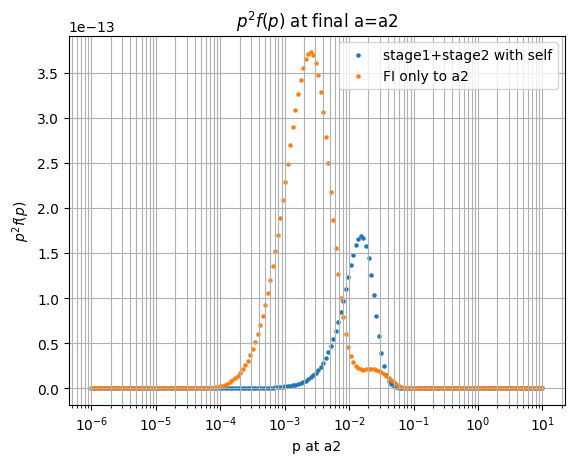

In [16]:
a_plot = torch.tensor(a2, device=device, dtype=dtype)

p = q / a_plot

p_cpu = p.detach().cpu().numpy()
f1_cpu = f_final.detach().cpu().numpy()
fFI_cpu2 = fFI2.detach().cpu().numpy()

plt.figure()
plt.scatter(p_cpu, p_cpu**2 * f1_cpu, s=5, label="stage1+stage2 with self")
plt.scatter(p_cpu, p_cpu**2 * fFI_cpu2, s=5, label="FI only to a2")

plt.xlabel("p at a2")
plt.xscale("log")
plt.ylabel(r"$p^2 f(p)$")
plt.yscale("linear")
plt.title(r"$p^2 f(p)$ at final a=a2")
plt.grid(True, which="both")
plt.legend()
plt.show()

# We now plot and compare 

In [14]:
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator
from scipy.special import kve

# --------------------------------------------------
# results directory
# --------------------------------------------------

RESULTS_DIR = Path("results2")

def list_saved_runs(results_dir=RESULTS_DIR):
    results_dir = Path(results_dir)
    runs = sorted([p for p in results_dir.iterdir() if p.is_dir()])
    for i, p in enumerate(runs):
        has_traj = (p / "trajectory.pt").exists()
        has_meta = (p / "metadata.json").exists()
        print(f"{i:02d}: {p.name} | trajectory.pt={has_traj} | metadata.json={has_meta}")
    return runs


runs = list_saved_runs(RESULTS_DIR)

00: hybrid_saved_N180_lamself1.0e-04_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | trajectory.pt=True | metadata.json=True
01: hybrid_saved_N180_lamself1.0e-05_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | trajectory.pt=True | metadata.json=True
02: hybrid_saved_N180_lamself5.0e-04_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | trajectory.pt=True | metadata.json=True
03: hybrid_saved_N180_lamself5.0e-05_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | trajectory.pt=True | metadata.json=True
04: hybrid_saved_N180_lamself5.0e-06_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | trajectory.pt=True | metadata.json=True


In [111]:
run_dir = runs[4]   # change index as needed
print("Selected:", run_dir)

Selected: results2/hybrid_saved_N180_lamself5.0e-06_Ng12_batch36_nw400_rk4spw1_af6.0e+04


In [112]:
def load_hybrid_run(run_dir, map_location="cpu"):
    run_dir = Path(run_dir)

    traj_path = run_dir / "trajectory.pt"
    meta_path = run_dir / "metadata.json"

    traj = torch.load(traj_path, map_location=map_location)

    metadata = None
    if meta_path.exists():
        with open(meta_path, "r") as f:
            metadata = json.load(f)

    return traj, metadata


traj, metadata = load_hybrid_run(run_dir)

print("Loaded:", run_dir.name)
print("traj keys:", traj.keys())
print("metadata keys:", metadata.keys() if metadata is not None else None)

a_snap = traj["a"].detach().cpu().numpy()
f_snap = traj["f"].detach().cpu().numpy()

print("a_snap:", a_snap.shape)
print("f_snap:", f_snap.shape)
print("a range:", a_snap[0], a_snap[-1])

Loaded: hybrid_saved_N180_lamself5.0e-06_Ng12_batch36_nw400_rk4spw1_af6.0e+04
traj keys: dict_keys(['u', 'a', 'f', 'u_final', 'a_final', 'f_final', 'mode_hist', 'gamma_over_H_hist', 'gamma_check_a_hist', 'a_switch', 'heun_status', 'rk4_status_hist', 'settings'])
metadata keys: dict_keys(['N_grid', 'Ng', 'a0', 'af', 'batch_size', 'created_at', 'g_trilinear', 'gamma_over_H_on', 'gchi', 'heun_print_every_accepted', 'heun_store_every_accepted', 'lam_portal', 'lam_self', 'mX', 'm_chi', 'm_h', 'm_other2', 'mode', 'multiplicity2', 'n_windows', 'pref_FI', 'qmax', 'qmin', 'rk4_steps_per_window', 'rk4_store_every_steps', 'run_name', 'v_h'])
a_snap: (401,)
f_snap: (401, 180)
a range: 1.0 60000.00000000002


/tmp/ipykernel_9989/2738518039.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  traj = torch.load(traj_path, map_location=map_location)


In [113]:
def get_snapshot(traj, q, idx=-1):
    """
    Extract one saved snapshot.

    Returns:
        a, q, p, f, p2f
    """
    a_arr = traj["a"].detach().cpu().numpy()
    f_arr = traj["f"].detach().cpu().numpy()

    a = float(a_arr[idx])
    f = f_arr[idx]

    q = np.asarray(q, dtype=float)
    p = q / a
    p2f = p**2 * f

    return {
        "a": a,
        "q": q,
        "p": p,
        "f": f,
        "p2f": p2f,
    }


def make_loglog_p2f_interpolator(p, p2f, floor=1e-300):
    """
    Interpolate y(p) = p^2 f(p) in log-log space using PCHIP.
    """
    p = np.asarray(p, dtype=float)
    p2f = np.asarray(p2f, dtype=float)

    mask = np.isfinite(p) & np.isfinite(p2f) & (p > 0.0) & (p2f > 0.0)

    p_use = p[mask]
    y_use = p2f[mask]

    if len(p_use) < 2:
        raise ValueError("Need at least two positive finite points for interpolation.")

    order = np.argsort(p_use)
    p_use = p_use[order]
    y_use = y_use[order]

    logp = np.log(p_use)
    logy = np.log(np.maximum(y_use, floor))

    interp_logy = PchipInterpolator(logp, logy, extrapolate=False)

    p_min = p_use[0]
    p_max = p_use[-1]

    def y_of_p(p_new):
        p_arr = np.asarray(p_new, dtype=float)
        scalar_input = np.ndim(p_arr) == 0
        p_arr = np.atleast_1d(p_arr)

        out = np.zeros_like(p_arr, dtype=float)
        inside = (p_arr >= p_min) & (p_arr <= p_max) & (p_arr > 0.0)

        out[inside] = np.exp(interp_logy(np.log(p_arr[inside])))

        if scalar_input:
            return float(out[0])

        return out

    return y_of_p


def n_eq_MB_stable(T, m):
    """
    Stable MB equilibrium number density:

        n_eq = m^2 T K_2(m/T) / (2 pi^2)

    using kve to avoid underflow.
    """
    T = float(T)
    m = float(m)

    if T <= 0:
        return 0.0

    x = m / T
    return (m**2 * T / (2.0 * np.pi**2)) * np.exp(-x) * kve(2, x)


def p2f_MB_from_n_T(p, m, n, T):
    """
    Stable MB distribution normalized to physical number density n.

    Avoids directly computing z exp(-E/T), which can underflow.
    """
    p = np.asarray(p, dtype=float)
    m = float(m)
    n = float(n)
    T = float(T)

    E = np.sqrt(p**2 + m**2)

    if T <= 0 or n <= 0:
        f = np.zeros_like(p)
        return f, p**2 * f

    x = m / T
    K2_scaled = kve(2, x)

    amp = n * (2.0 * np.pi**2) / max(m**2 * T * K2_scaled, 1e-300)

    f = amp * np.exp(-(E - m) / T)
    p2f = p**2 * f

    return f, p2f

In [114]:
import numpy as np

def reconstruct_log_q_from_metadata(metadata):
    N = int(metadata["N_grid"])
    qmin = float(metadata["qmin"])
    qmax = float(metadata["qmax"])
    return np.logspace(np.log10(qmin), np.log10(qmax), N)

q_np = reconstruct_log_q_from_metadata(metadata)

print("q_np shape:", q_np.shape)
print("q range:", q_np[0], q_np[-1])

q_np shape: (180,)
q range: 0.1 1000000.0


In [115]:
def compute_moments_from_q_snapshot(q, f, a, m, g=1.0):
    """
    Compute physical moments from a saved f(q,a) snapshot.
    """
    q = np.asarray(q, dtype=float)
    f = np.asarray(f, dtype=float)

    a = float(a)
    m = float(m)
    g = float(g)

    p = q / a
    E = np.sqrt(p**2 + m**2)
    v = p / E

    pref = g / (2.0 * np.pi**2)

    # physical density integrals using dq
    n = pref * np.trapezoid(q**2 * f, q) / a**3
    rho = pref * np.trapezoid(q**2 * E * f, q) / a**3
    P = pref * np.trapezoid(q**2 * (p**2 / (3.0 * E)) * f, q) / a**3

    w = P / max(rho, 1e-300)
    Tkin = P / max(n, 1e-300)
    avg_E = rho / max(n, 1e-300)

    avg_p = pref * np.trapezoid(q**2 * p * f, q) / a**3 / max(n, 1e-300)
    avg_v = pref * np.trapezoid(q**2 * v * f, q) / a**3 / max(n, 1e-300)
    avg_v2 = pref * np.trapezoid(q**2 * v**2 * f, q) / a**3 / max(n, 1e-300)
    v_rms = np.sqrt(max(avg_v2, 0.0))

    return {
        "a": a,
        "n": n,
        "rho": rho,
        "P": P,
        "w": w,
        "Tkin": Tkin,
        "avg_E": avg_E,
        "avg_p": avg_p,
        "avg_v": avg_v,
        "avg_v2": avg_v2,
        "v_rms": v_rms,
    }


def compute_moments_along_trajectory(traj, q, m, g=1.0):
    a_arr = traj["a"].detach().cpu().numpy()
    f_arr = traj["f"].detach().cpu().numpy()

    rows = []

    for i, (a, f) in enumerate(zip(a_arr, f_arr)):
        mom = compute_moments_from_q_snapshot(q=q, f=f, a=a, m=m, g=g)
        mom["idx"] = i

        if "mode_hist" in traj:
            mom["mode"] = traj["mode_hist"][i]
        else:
            mom["mode"] = ""

        rows.append(mom)

    return rows


mchi = float(metadata["m_chi"])
moments = compute_moments_along_trajectory(traj, q_np, m=mchi, g=1.0)

print("Final moments:")
for k, v in moments[-1].items():
    if isinstance(v, float):
        print(f"{k:10s} = {v:.6e}")
    else:
        print(f"{k:10s} = {v}")

Final moments:
a          = 6.000000e+04
n          = 6.324875e-16
rho        = 3.167770e-16
P          = 3.536619e-19
w          = 1.116438e-03
Tkin       = 5.591603e-04
avg_E      = 5.008431e-01
avg_p      = 1.829695e-02
avg_v      = 3.637017e-02
avg_v2     = 3.320149e-03
v_rms      = 5.762074e-02
idx        = 400
mode       = FI_RK4


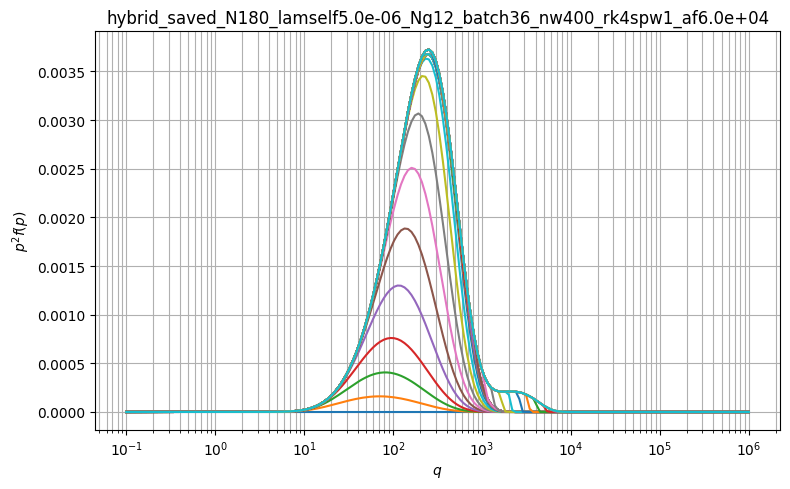

In [116]:
def choose_snapshot_indices(n, nsamples=6):
    if n <= nsamples:
        return list(range(n))

    idx = np.linspace(0, n - 1, nsamples).round().astype(int)
    return sorted(set(idx.tolist()))


def plot_p2f_snapshots(traj, q, indices=None, nsamples=6, title=None):
    a_arr = traj["a"].detach().cpu().numpy()
    f_arr = traj["f"].detach().cpu().numpy()

    if indices is None:
        indices = choose_snapshot_indices(len(a_arr), nsamples=nsamples)

    plt.figure(figsize=(8, 5))

    for i in indices:
        a = float(a_arr[i])
        f = f_arr[i]
        p = q #/ a
        p2f = p**2 * f

        if "mode_hist" in traj:
            label = fr"$a={a:.2e}$, {traj['mode_hist'][i]}"
        else:
            label = fr"$a={a:.2e}$"

        plt.plot(p, p2f, label=label)

    plt.xscale("log")
    plt.yscale("linear")
    plt.xlabel(r"$q$")
    plt.ylabel(r"$p^2 f(p)$")

    if title is None:
        title = r"Saved fBE snapshots"

    plt.title(title)
    plt.grid(True, which="both")
    #plt.legend()
    plt.tight_layout()
    plt.show()


plot_p2f_snapshots(traj, q_np, nsamples=50, title=run_dir.name)

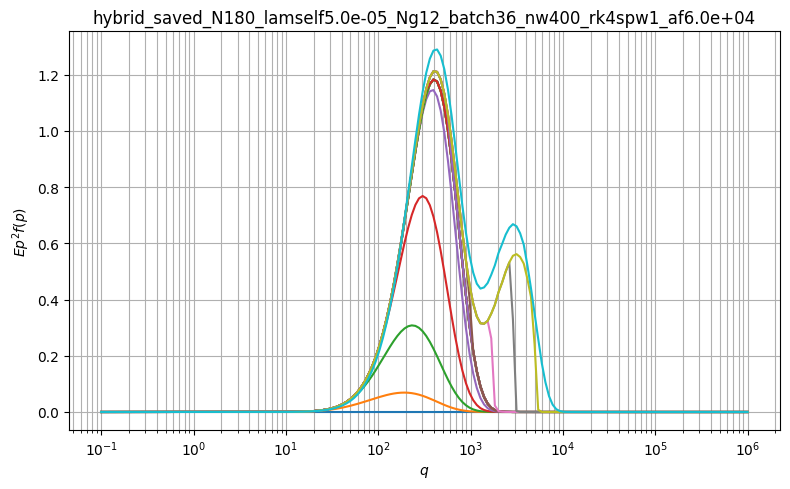

In [104]:
def choose_snapshot_indices(n, nsamples=6):
    if n <= nsamples:
        return list(range(n))

    idx = np.linspace(0, n - 1, nsamples).round().astype(int)
    return sorted(set(idx.tolist()))


def plot_p2f_snapshots(traj, q, indices=None, nsamples=6, title=None):
    a_arr = traj["a"].detach().cpu().numpy()
    f_arr = traj["f"].detach().cpu().numpy()

    if indices is None:
        indices = choose_snapshot_indices(len(a_arr), nsamples=nsamples)

    plt.figure(figsize=(8, 5))

    for i in indices:
        a = float(a_arr[i])
        f = f_arr[i]
        p = q #/ a
        p2f = p**2 * f

        if "mode_hist" in traj:
            label = fr"$a={a:.2e}$, {traj['mode_hist'][i]}"
        else:
            label = fr"$a={a:.2e}$"

        plt.plot(p, p*p2f, label=label)

    plt.xscale("log")
    plt.yscale("linear")
    plt.xlabel(r"$q$")
    plt.ylabel(r"$Ep^2 f(p)$")

    if title is None:
        title = r"Saved fBE snapshots"

    plt.title(title)
    plt.grid(True, which="both")
    #plt.legend()
    plt.tight_layout()
    plt.show()


plot_p2f_snapshots(traj, q_np, nsamples=20, title=run_dir.name)

a      = 6.000000e+04
Tkin   = 5.591603e-04
n      = 6.324875e-16
neq    = 0.000000e+00
log z  = 6.557787e+02
z      = 6.324875e+284


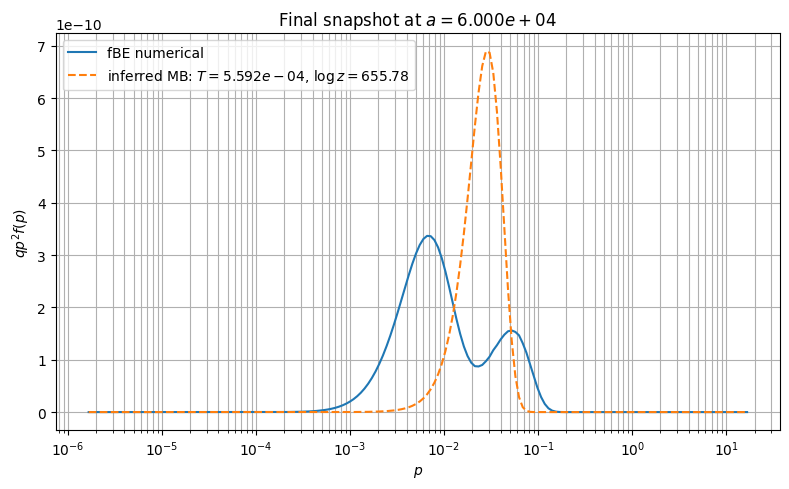

/tmp/ipykernel_9989/2387661740.py:66: RuntimeWarning: divide by zero encountered in log10
  plt.plot(p, np.log10(p2f / np.maximum(mb["p2f_MB"], 1e-300)), label="fBE / inferred MB")


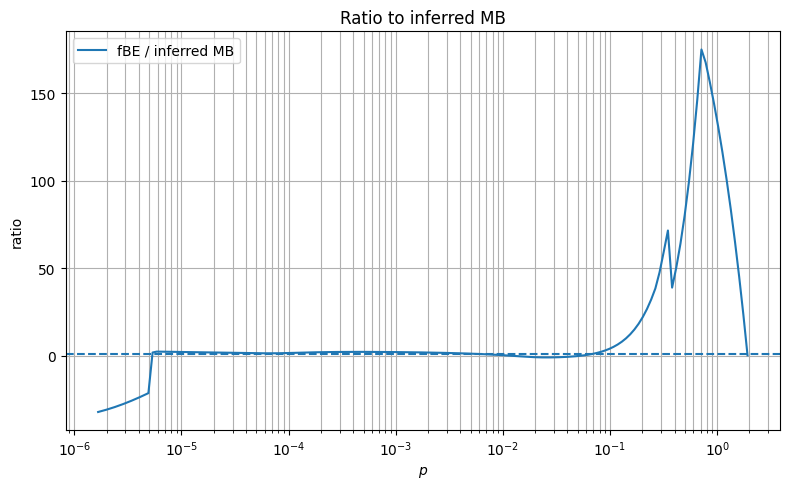

In [126]:
def infer_MB_from_snapshot(q, f, a, m, g=1.0):
    """
    Infer a Maxwell-Boltzmann-like temperature from P/n,
    then normalize the MB curve to the actual number density n.
    """
    mom = compute_moments_from_q_snapshot(q=q, f=f, a=a, m=m, g=g)

    T = mom["Tkin"]
    n = mom["n"]

    neq = n_eq_MB_stable(T, m)
    logz = np.log(max(n, 1e-300)) - np.log(max(neq, 1e-300))
    z = np.exp(logz) if logz < 700 else np.inf

    p = q / a
    f_MB, p2f_MB = p2f_MB_from_n_T(p=p, m=m, n=n, T=T)

    return {
        "T": T,
        "n": n,
        "neq": neq,
        "z": z,
        "logz": logz,
        "moments": mom,
        "p": p,
        "f_MB": f_MB,
        "p2f_MB": p2f_MB,
    }


def plot_final_against_inferred_MB(traj, q, m, g=1.0, idx=-1):
    snap = get_snapshot(traj, q, idx=idx)
    mb = infer_MB_from_snapshot(
        q=snap["q"],
        f=snap["f"],
        a=snap["a"],
        m=m,
        g=g,
    )
    a=snap["a"]
    p = snap["p"]
    p2f = snap["p2f"]

    print(f"a      = {snap['a']:.6e}")
    print(f"Tkin   = {mb['T']:.6e}")
    print(f"n      = {mb['n']:.6e}")
    print(f"neq    = {mb['neq']:.6e}")
    print(f"log z  = {mb['logz']:.6e}")
    print(f"z      = {mb['z']:.6e}")

    plt.figure(figsize=(8, 5))
    plt.plot(p, q*p2f, label="fBE numerical")
    plt.plot(p, q*mb["p2f_MB"], "--", label=fr"inferred MB: $T={mb['T']:.3e}$, $\log z={mb['logz']:.2f}$")

    plt.xscale("log")
    plt.yscale("linear")
    plt.xlabel(r"$p$")
    plt.ylabel(r"$q p^2 f(p)$")
    plt.title(fr"Final snapshot at $a={snap['a']:.3e}$")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(p, np.log10(p2f / np.maximum(mb["p2f_MB"], 1e-300)), label="fBE / inferred MB")
    plt.axhline(1.0, linestyle="--")

    plt.xscale("log")
    plt.xlabel(r"$p$")
    plt.ylabel(r"ratio")
    plt.title("Ratio to inferred MB")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mb


mb_final = plot_final_against_inferred_MB(traj, q_np, m=mchi, g=1.0, idx=-1)

In [127]:
def cbe_distribution_on_p_grid_stable(p, a, m, Ns, Ts):
    """
    Build cBE Maxwell-Boltzmann distribution on a physical p grid.
    Assumes:
        Ns(a) = comoving number N = a^3 n
        Ts(a) = dark-sector temperature parameter
    """
    p = np.asarray(p, dtype=float)

    a = float(a)
    m = float(m)

    T_val = float(Ts(a))
    N_val = float(Ns(a))
    n_val = N_val / a**3

    f_cbe, p2f_cbe = p2f_MB_from_n_T(
        p=p,
        m=m,
        n=n_val,
        T=T_val,
    )

    neq_val = n_eq_MB_stable(T_val, m)
    logz_val = np.log(max(n_val, 1e-300)) - np.log(max(neq_val, 1e-300))
    z_val = np.exp(logz_val) if logz_val < 700 else np.inf

    return {
        "T": T_val,
        "N": N_val,
        "n": n_val,
        "neq": neq_val,
        "z": z_val,
        "logz": logz_val,
        "f": f_cbe,
        "p2f": p2f_cbe,
    }


def plot_final_against_MB_and_cBE(traj, q, m, Ns=None, Ts=None, g=1.0, idx=-1):
    snap = get_snapshot(traj, q, idx=idx)
    mb = infer_MB_from_snapshot(
        q=snap["q"],
        f=snap["f"],
        a=snap["a"],
        m=m,
        g=g,
    )

    p = snap["p"]
    p2f = snap["p2f"]

    plt.figure(figsize=(8, 5))
    plt.plot(p, p2f, label="fBE numerical")
    plt.plot(p, mb["p2f_MB"], "--", label=fr"inferred MB: $T={mb['T']:.3e}$")

    cbe = None
    if Ns is not None and Ts is not None:
        cbe = cbe_distribution_on_p_grid_stable(
            p=p,
            a=snap["a"],
            m=m,
            Ns=Ns,
            Ts=Ts,
        )

        plt.plot(
            p,
            cbe["p2f"],
            ":",
            linewidth=2.5,
            label=fr"cBE MB: $T={cbe['T']:.3e}$"
        )

        print("cBE:")
        print(f"  T     = {cbe['T']:.6e}")
        print(f"  N     = {cbe['N']:.6e}")
        print(f"  n     = {cbe['n']:.6e}")
        print(f"  neq   = {cbe['neq']:.6e}")
        print(f"  log z = {cbe['logz']:.6e}")

    print("fBE inferred MB:")
    print(f"  a     = {snap['a']:.6e}")
    print(f"  Tkin  = {mb['T']:.6e}")
    print(f"  n     = {mb['n']:.6e}")
    print(f"  neq   = {mb['neq']:.6e}")
    print(f"  log z = {mb['logz']:.6e}")

    plt.xscale("log")
    plt.yscale("linear")
    plt.xlabel(r"$p$")
    plt.ylabel(r"$p^2 f(p)$")
    plt.title(fr"Final comparison at $a={snap['a']:.3e}$")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if cbe is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(p, p2f / np.maximum(cbe["p2f"], 1e-300), label="fBE / cBE")
        plt.plot(p, mb["p2f_MB"] / np.maximum(cbe["p2f"], 1e-300), "--", label="inferred MB / cBE")
        plt.axhline(1.0, linestyle="--")

        plt.xscale("log")
        plt.xlabel(r"$p$")
        plt.ylabel("ratio to cBE")
        plt.title("Ratio to cBE")
        plt.grid(True, which="both")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "snapshot": snap,
        "inferred_MB": mb,
        "cBE": cbe,
    }

In [128]:
def plot_moment_evolution_skip_tiny(
    moments,
    n_min=1e-250,
    rho_min=1e-250,
    P_min=1e-250,
    Ts=None,
    Tsm=None,
    n_Ts_points=500,
):
    a = np.array([row["a"] for row in moments])
    n = np.array([row["n"] for row in moments])
    rho = np.array([row["rho"] for row in moments])
    P = np.array([row["P"] for row in moments])
    w = np.array([row["w"] for row in moments])
    Tkin = np.array([row["Tkin"] for row in moments])
    vrms = np.array([row["v_rms"] for row in moments])

    # --------------------------------------------------
    # n, rho, P
    # --------------------------------------------------

    plt.figure(figsize=(8, 5))

    mask_n = np.isfinite(n) & (n > n_min)
    mask_rho = np.isfinite(rho) & (rho > rho_min)
    mask_P = np.isfinite(P) & (P > P_min)

    if np.any(mask_n):
        plt.loglog(a[mask_n], n[mask_n], label=r"$n$")
    if np.any(mask_rho):
        plt.loglog(a[mask_rho], rho[mask_rho], label=r"$\rho$")
    if np.any(mask_P):
        plt.loglog(a[mask_P], P[mask_P], label=r"$P$")

    plt.xlabel(r"$a$")
    plt.ylabel("physical moments")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # w and v_rms
    # --------------------------------------------------

    mask_aux = np.isfinite(w) & np.isfinite(vrms) & (rho > rho_min)

    plt.figure(figsize=(8, 5))
    if np.any(mask_aux):
        plt.semilogx(a[mask_aux], w[mask_aux], label=r"$w=P/\rho$")
        plt.semilogx(a[mask_aux], vrms[mask_aux], label=r"$v_{\rm rms}$")

    plt.xlabel(r"$a$")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Tkin plus cBE temperature(s)
    # --------------------------------------------------

    mask_T = np.isfinite(Tkin) & (Tkin > 0.0) & (n > n_min)

    plt.figure(figsize=(8, 5))

    if np.any(mask_T):
        plt.loglog(a[mask_T], Tkin[mask_T], label=r"$T_{\rm kin}=P/n$")

    # Overlay Ts(a), if provided
    if Ts is not None and np.any(mask_T):
        a_T_min = np.min(a[mask_T])
        a_T_max = np.max(a[mask_T])

        a_T_grid = np.logspace(np.log10(a_T_min), np.log10(a_T_max), n_Ts_points)
        Ts_grid = np.array([float(Ts(float(ai))) for ai in a_T_grid])

        mask_Ts = np.isfinite(Ts_grid) & (Ts_grid > 0.0)

        if np.any(mask_Ts):
            plt.loglog(
                a_T_grid[mask_Ts],
                Ts_grid[mask_Ts],
                "--",
                linewidth=2.5,
                label=r"$T_s(a)$ from cBE",
            )

    # Overlay Tsm(a), if provided
    if Tsm is not None and np.any(mask_T):
        a_T_min = np.min(a[mask_T])
        a_T_max = np.max(a[mask_T])

        a_T_grid = np.logspace(np.log10(a_T_min), np.log10(a_T_max), n_Ts_points)
        Tsm_grid = np.array([float(Tsm(float(ai))) for ai in a_T_grid])

        mask_Tsm = np.isfinite(Tsm_grid) & (Tsm_grid > 0.0)

        if np.any(mask_Tsm):
            plt.loglog(
                a_T_grid[mask_Tsm],
                Tsm_grid[mask_Tsm],
                ":",
                linewidth=2.5,
                label=r"$T_{s,m}(a)$",
            )

    plt.xlabel(r"$a$")
    plt.ylabel("temperature")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

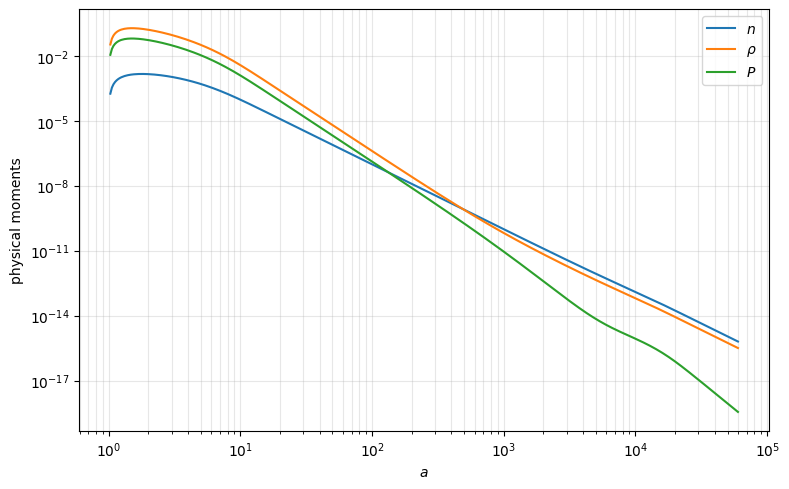

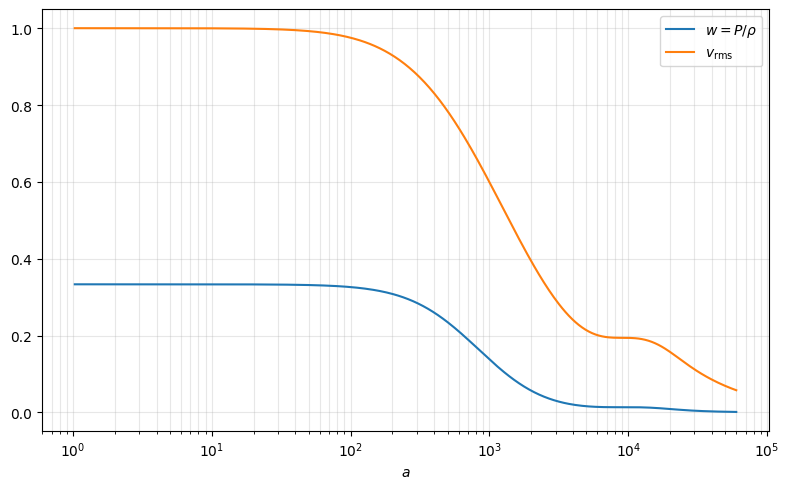

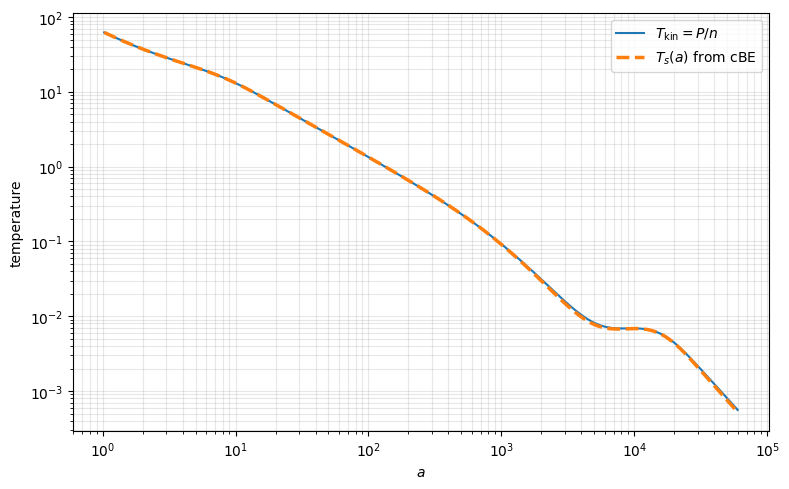

In [129]:
plot_moment_evolution_skip_tiny(
    moments,
    n_min=1e-150,
    rho_min=1e-150,
    P_min=1e-150,
    Ts=Ts,
)

In [73]:
def closest_snapshot_index(traj, a_target):
    a_arr = traj["a"].detach().cpu().numpy()
    idx = int(np.argmin(np.abs(a_arr - float(a_target))))
    return idx, float(a_arr[idx])


def get_snapshot_qspace(traj, q, idx):
    a_arr = traj["a"].detach().cpu().numpy()
    f_arr = traj["f"].detach().cpu().numpy()

    a = float(a_arr[idx])
    f = f_arr[idx]

    q = np.asarray(q, dtype=float)
    p = q / a

    return {
        "idx": idx,
        "a": a,
        "q": q,
        "p": p,
        "f": f,
        "p2f": p**2 * f,
        "q_p2f": q * p**2 * f,
        "q3f_over_a2": q**3 * f / a**2,
    }

In [78]:
from pathlib import Path
import json
import torch
import numpy as np

RESULTS_DIR = Path("results2")

def load_hybrid_run(run_dir, map_location="cpu"):
    run_dir = Path(run_dir)

    traj_path = run_dir / "trajectory.pt"
    meta_path = run_dir / "metadata.json"

    if not traj_path.exists():
        raise FileNotFoundError(f"Missing {traj_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing {meta_path}")

    traj = torch.load(traj_path, map_location=map_location)

    with open(meta_path, "r") as f:
        metadata = json.load(f)

    return traj, metadata


def reconstruct_log_q_from_metadata(metadata):
    N = int(metadata["N_grid"])
    qmin = float(metadata["qmin"])
    qmax = float(metadata["qmax"])
    return np.logspace(np.log10(qmin), np.log10(qmax), N)


def load_all_runs_matching(pattern="hybrid_saved_*", results_dir=RESULTS_DIR):
    results_dir = Path(results_dir)
    run_dirs = sorted(results_dir.glob(pattern))

    loaded = {}

    for rd in run_dirs:
        traj_path = rd / "trajectory.pt"
        meta_path = rd / "metadata.json"

        if not traj_path.exists() or not meta_path.exists():
            continue

        traj, metadata = load_hybrid_run(rd)
        q = reconstruct_log_q_from_metadata(metadata)

        loaded[rd.name] = {
            "run_dir": rd,
            "traj": traj,
            "metadata": metadata,
            "q": q,
        }

    return loaded


loaded_runs = load_all_runs_matching(
    pattern="hybrid_saved_*",
    results_dir=RESULTS_DIR,
)

print("Loaded runs:")
for name, obj in loaded_runs.items():
    print(
        f"{name} | "
        f"lam_self={obj['metadata']['lam_self']:.1e} | "
        f"snapshots={len(obj['traj']['a'])}"
    )

loaded_runs = load_all_runs_matching(
    pattern="*",
    results_dir=RESULTS_DIR,
)

loaded_runs[name]["traj"]
loaded_runs[name]["metadata"]
loaded_runs[name]["q"]

/tmp/ipykernel_9989/110506851.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  traj = torch.load(traj_path, map_location=map_location)


Loaded runs:
hybrid_saved_N180_lamself1.0e-04_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | lam_self=1.0e-04 | snapshots=276
hybrid_saved_N180_lamself1.0e-05_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | lam_self=1.0e-05 | snapshots=401
hybrid_saved_N180_lamself5.0e-04_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | lam_self=5.0e-04 | snapshots=137
hybrid_saved_N180_lamself5.0e-05_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | lam_self=5.0e-05 | snapshots=370
hybrid_saved_N180_lamself5.0e-06_Ng12_batch36_nw400_rk4spw1_af6.0e+04 | lam_self=5.0e-06 | snapshots=401


array([1.00000000e-01, 1.09422377e-01, 1.19732566e-01, 1.31014220e-01,
       1.43358874e-01, 1.56866688e-01, 1.71647259e-01, 1.87820511e-01,
       2.05517667e-01, 2.24882317e-01, 2.46071577e-01, 2.69257369e-01,
       2.94627814e-01, 3.22388757e-01, 3.52765442e-01, 3.86004332e-01,
       4.22375116e-01, 4.62172892e-01, 5.05720565e-01, 5.53371464e-01,
       6.05512210e-01, 6.62565854e-01, 7.24995307e-01, 7.93307099e-01,
       8.68055486e-01, 9.49846947e-01, 1.03934511e+00, 1.13727612e+00,
       1.24443457e+00, 1.36168989e+00, 1.48999344e+00, 1.63038625e+00,
       1.78400739e+00, 1.95210329e+00, 2.13603782e+00, 2.33730336e+00,
       2.55753290e+00, 2.79851329e+00, 3.06219977e+00, 3.35073178e+00,
       3.66645036e+00, 4.01191715e+00, 4.38993511e+00, 4.80357135e+00,
       5.25618196e+00, 5.75143924e+00, 6.29336154e+00, 6.88634579e+00,
       7.53520326e+00, 8.24519853e+00, 9.02209223e+00, 9.87218779e+00,
       1.08023825e+01, 1.18202238e+01, 1.29339698e+01, 1.41526572e+01,
      

In [79]:
def plot_lambdas_at_closest_a(
    loaded_runs,
    a_target,
    quantity="q_p2f",
    title=None,
):
    """
    quantity options:
        "f"       -> f(q)
        "p2f"     -> p^2 f(q)
        "q_p2f"   -> q p^2 f(q) = q^3 f / a^2
    """

    plt.figure(figsize=(8, 5))

    used = []

    for name, obj in sorted(
        loaded_runs.items(),
        key=lambda item: float(item[1]["metadata"]["lam_self"])
    ):
        traj = obj["traj"]
        meta = obj["metadata"]
        q = obj["q"]

        idx, a_used = closest_snapshot_index(traj, a_target)
        snap = get_snapshot_qspace(traj, q, idx)

        lam_self = float(meta["lam_self"])
        y = snap[quantity]

        plt.plot(
            q,
            y,
            label=fr"$\lambda_{{\rm self}}={lam_self:.1e}$, $a={a_used:.2e}$"
        )

        used.append((lam_self, idx, a_used))

    plt.xscale("log")
    plt.yscale("linear")
    plt.xlabel(r"$q$")

    if quantity == "f":
        ylabel = r"$f(q)$"
    elif quantity == "p2f":
        ylabel = r"$p^2 f(q)$"
    elif quantity == "q_p2f":
        ylabel = r"$q\,p^2 f(q)=q^3 f/a^2$"
    else:
        ylabel = quantity

    plt.ylabel(ylabel)

    if title is None:
        title = fr"Closest saved snapshots to $a={a_target:.2e}$"

    plt.title(title)
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Used snapshots:")
    for lam_self, idx, a_used in used:
        print(f"lam_self={lam_self:.1e} | idx={idx:4d} | a_used={a_used:.6e}")

    return used

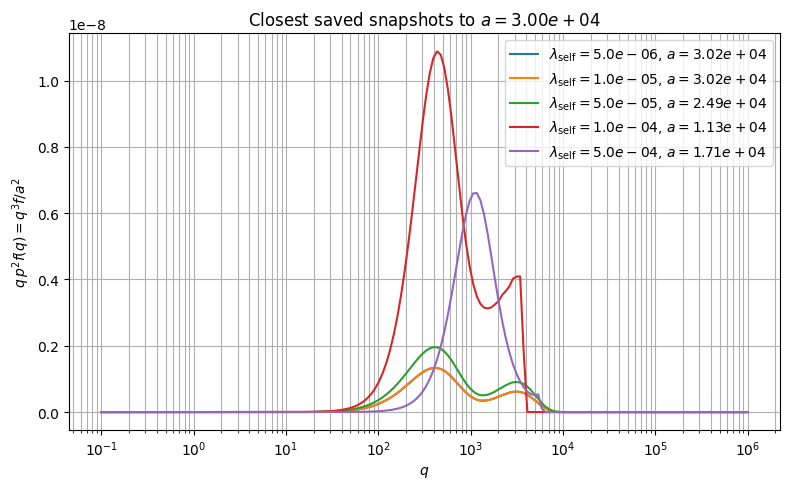

Used snapshots:
lam_self=5.0e-06 | idx= 375 | a_used=3.016594e+04
lam_self=1.0e-05 | idx= 375 | a_used=3.016594e+04
lam_self=5.0e-05 | idx= 368 | a_used=2.488279e+04
lam_self=1.0e-04 | idx= 273 | a_used=1.125551e+04
lam_self=5.0e-04 | idx= 135 | a_used=1.707351e+04


In [106]:
used = plot_lambdas_at_closest_a(
    loaded_runs,
    a_target=3e4,
    quantity="q_p2f",
)

In [81]:
def get_largest_lambda_run(loaded_runs):
    return max(
        loaded_runs.items(),
        key=lambda item: float(item[1]["metadata"]["lam_self"])
    )


def plot_final_lambdas_with_MB_from_largest_lambda(
    loaded_runs,
    quantity="q_p2f",
):
    largest_name, largest_obj = get_largest_lambda_run(loaded_runs)

    traj_ref = largest_obj["traj"]
    meta_ref = largest_obj["metadata"]
    q_ref = largest_obj["q"]

    m_ref = float(meta_ref["m_chi"])
    lam_ref = float(meta_ref["lam_self"])

    idx_ref = -1
    snap_ref = get_snapshot_qspace(traj_ref, q_ref, idx_ref)

    mb_ref = infer_MB_from_snapshot(
        q=q_ref,
        f=snap_ref["f"],
        a=snap_ref["a"],
        m=m_ref,
        g=1.0,
    )

    plt.figure(figsize=(8, 5))

    # Plot all numerical final spectra
    for name, obj in sorted(
        loaded_runs.items(),
        key=lambda item: float(item[1]["metadata"]["lam_self"])
    ):
        traj = obj["traj"]
        meta = obj["metadata"]
        q = obj["q"]

        lam_self = float(meta["lam_self"])
        snap = get_snapshot_qspace(traj, q, idx=-1)

        plt.plot(
            q,
            snap[quantity],
            label=fr"fBE, $\lambda_{{\rm self}}={lam_self:.1e}$"
        )

    # MB curve from largest lambda, evaluated on q_ref
    q = q_ref
    a = snap_ref["a"]
    p = q / a

    if quantity == "f":
        y_mb = mb_ref["f_MB"]
        ylabel = r"$f(q)$"
    elif quantity == "p2f":
        y_mb = p**2 * mb_ref["f_MB"]
        ylabel = r"$p^2 f(q)$"
    elif quantity == "q_p2f":
        y_mb = q * p**2 * mb_ref["f_MB"]
        ylabel = r"$q\,p^2 f(q)=q^3 f/a^2$"
    else:
        raise ValueError("Unknown quantity.")

    plt.plot(
        q,
        y_mb,
        "--",
        linewidth=2.5,
        label=fr"inferred MB from largest $\lambda={lam_ref:.1e}$"
    )

    plt.xscale("log")
    plt.yscale("linear")
    plt.xlabel(r"$q$")
    plt.ylabel(ylabel)
    plt.title(fr"Final spectra at $a={a:.2e}$")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Reference MB inferred from largest lambda:")
    print(f"lambda_self = {lam_ref:.6e}")
    print(f"a           = {a:.6e}")
    print(f"T_MB        = {mb_ref['T']:.6e}")
    print(f"n_MB norm   = {mb_ref['n']:.6e}")
    print(f"log z       = {mb_ref['logz']:.6e}")

    return mb_ref

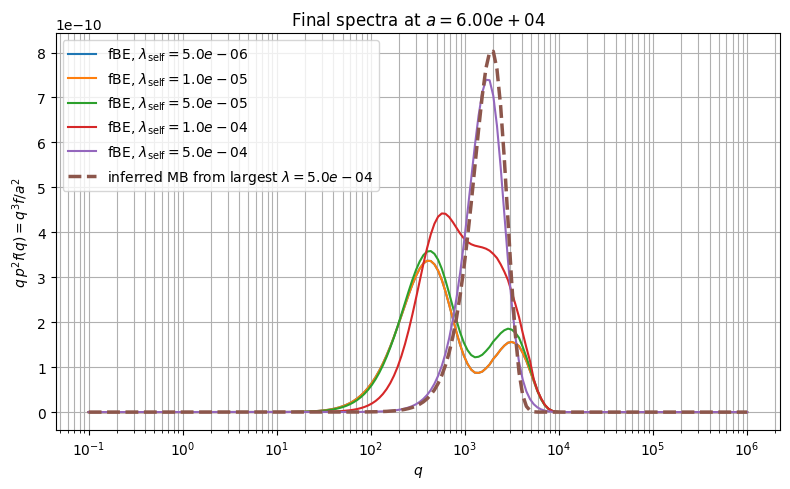

Reference MB inferred from largest lambda:
lambda_self = 5.000000e-04
a           = 6.000000e+04
T_MB        = 6.838797e-04
n_MB norm   = 7.369887e-16
log z       = 6.559316e+02


In [82]:
mb_largest = plot_final_lambdas_with_MB_from_largest_lambda(
    loaded_runs,
    quantity="q_p2f",
)

In [143]:
def plot_final_lambdas_with_MB_and_cBE(
    loaded_runs,
    Ns=None,
    Ts=None,
    quantity="q_p2f",
    cmap_name="inferno",
    yscale="linear",
    normalize=False,
    eps=1e-300,
    title=None,
    print_diagnostics=True,
    xlim=(1e1, 1e6),
    ylim=None,
    line_width=1.3,
):
    """
    Final comparison of fBE spectra for different lambdas, plus inferred MB
    from the largest lambda and optional cBE output.

    quantity:
        "f"      -> f(q)
        "p2f"    -> p^2 f(q)
        "q_p2f"  -> q p^2 f(q) = q^3 f(q)/a^2

    normalize:
        If True, each fBE curve is divided by its own max.
        Useful for comparing shapes when amplitudes differ strongly.
    """

    largest_name, largest_obj = get_largest_lambda_run(loaded_runs)

    traj_ref = largest_obj["traj"]
    meta_ref = largest_obj["metadata"]
    q_ref = largest_obj["q"]

    m_ref = float(meta_ref["m_chi"])
    lam_ref = float(meta_ref["lam_self"])

    snap_ref = get_snapshot_qspace(traj_ref, q_ref, idx=-1)

    mb_ref = infer_MB_from_snapshot(
        q=q_ref,
        f=snap_ref["f"],
        a=snap_ref["a"],
        m=m_ref,
        g=1.0,
    )

    q = q_ref
    a = snap_ref["a"]
    p = q / a

    sorted_items = sorted(
        loaded_runs.items(),
        key=lambda item: float(item[1]["metadata"]["lam_self"])
    )

    colors = get_cmap_colors(
        len(sorted_items),
        cmap_name=cmap_name,
        vmin=0.18,
        vmax=0.88,
    )

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    diagnostics = []

    # --------------------------------------------------
    # Numerical fBE spectra
    # --------------------------------------------------

    for color, (name, obj) in zip(colors, sorted_items):
        traj = obj["traj"]
        meta = obj["metadata"]
        q_i = obj["q"]

        lam_self = float(meta["lam_self"])
        snap = get_snapshot_qspace(traj, q_i, idx=-1)

        y = np.asarray(snap[quantity], dtype=float)

        y_raw_max = np.nanmax(y)
        y_raw_min = np.nanmin(y)

        if normalize:
            y = y / max(y_raw_max, eps)

        # For log-y plots, avoid zeros killing the curve.
        if yscale == "log":
            y_plot = np.maximum(y, eps)
        else:
            y_plot = y

        ax.plot(
            q_i,
            y_plot,
            color=color,
            linewidth=2.1,
            label=fr"$\lambda_\mathrm{{self}}={lam_self:.1e}$"
        )

        diagnostics.append({
            "name": name,
            "lam_self": lam_self,
            "a_final": snap["a"],
            "y_min": y_raw_min,
            "y_max": y_raw_max,
            "finite": np.all(np.isfinite(y)),
            "positive_points": int(np.sum(y > 0.0)),
        })

    # --------------------------------------------------
    # Inferred MB from largest lambda
    # --------------------------------------------------

    if quantity == "f":
        y_mb = mb_ref["f_MB"]
        ylabel = r"$f(q)$"
    elif quantity == "p2f":
        y_mb = p**2 * mb_ref["f_MB"]
        ylabel = r"$p^2 f(q)$"
    elif quantity == "q_p2f":
        y_mb = q * p**2 * mb_ref["f_MB"]
        ylabel = r"$q\,p^2 f(q)=q^3 f(q)/a^2$"
    else:
        raise ValueError("Unknown quantity.")

    if normalize:
        y_mb = y_mb / max(np.nanmax(y_mb), eps)
        ylabel = ylabel + r" / max"

    if yscale == "log":
        y_mb_plot = np.maximum(y_mb, eps)
    else:
        y_mb_plot = y_mb

    ax.plot(
        q,
        y_mb_plot,
        color="black",
        linestyle="--",
        linewidth=line_width+0.4,
        label=fr"inferred MB, $\lambda_\mathrm{{self}}={lam_ref:.1e}$"
    )

    # --------------------------------------------------
    # cBE output
    # --------------------------------------------------

    cbe = None

    if Ns is not None and Ts is not None:
        cbe = cbe_distribution_on_p_grid_stable(
            p=p,
            a=a,
            m=m_ref,
            Ns=Ns,
            Ts=Ts,
        )

        if quantity == "f":
            y_cbe = cbe["f"]
        elif quantity == "p2f":
            y_cbe = p**2 * cbe["f"]
        elif quantity == "q_p2f":
            y_cbe = q * p**2 * cbe["f"]

        if normalize:
            y_cbe = y_cbe / max(np.nanmax(y_cbe), eps)

        if yscale == "log":
            y_cbe_plot = np.maximum(y_cbe, eps)
        else:
            y_cbe_plot = y_cbe

        ax.plot(
            q,
            y_cbe_plot,
            color="black",
            linestyle=":",
            linewidth=line_width+0.4,
            label=r"cBE MB"
        )

    # --------------------------------------------------
    # Axis style
    # --------------------------------------------------

    ax.set_xscale("log")
    ax.set_yscale(yscale)

    if xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(r"$q$")
    ax.set_ylabel(ylabel)

    if title is None:
        title = fr"Final comparison at $a={a:.2e}$"

    ax.set_title(title)
    ax.grid(True, which="both")
    ax.legend()

    fig.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Diagnostics
    # --------------------------------------------------

    if print_diagnostics:
        print("Curve diagnostics:")
        for row in diagnostics:
            print(
                f"lambda={row['lam_self']:.1e} | "
                f"a_final={row['a_final']:.6e} | "
                f"y_min={row['y_min']:.3e} | "
                f"y_max={row['y_max']:.3e} | "
                f"positive_points={row['positive_points']} | "
                f"finite={row['finite']}"
            )

        print()
        print("Reference largest lambda:")
        print(f"lambda_self = {lam_ref:.6e}")
        print(f"a_final     = {a:.6e}")
        print(f"T_inferred  = {mb_ref['T']:.6e}")
        print(f"n_inferred  = {mb_ref['n']:.6e}")
        print(f"log z       = {mb_ref['logz']:.6e}")

        if cbe is not None:
            print()
            print("cBE:")
            print(f"T_cBE       = {cbe['T']:.6e}")
            print(f"N_cBE       = {cbe['N']:.6e}")
            print(f"n_cBE       = {cbe['n']:.6e}")
            print(f"log z_cBE   = {cbe['logz']:.6e}")

    return {
        "MB_largest_lambda": mb_ref,
        "cBE": cbe,
        "diagnostics": diagnostics,
        "fig": fig,
        "ax": ax,
    }

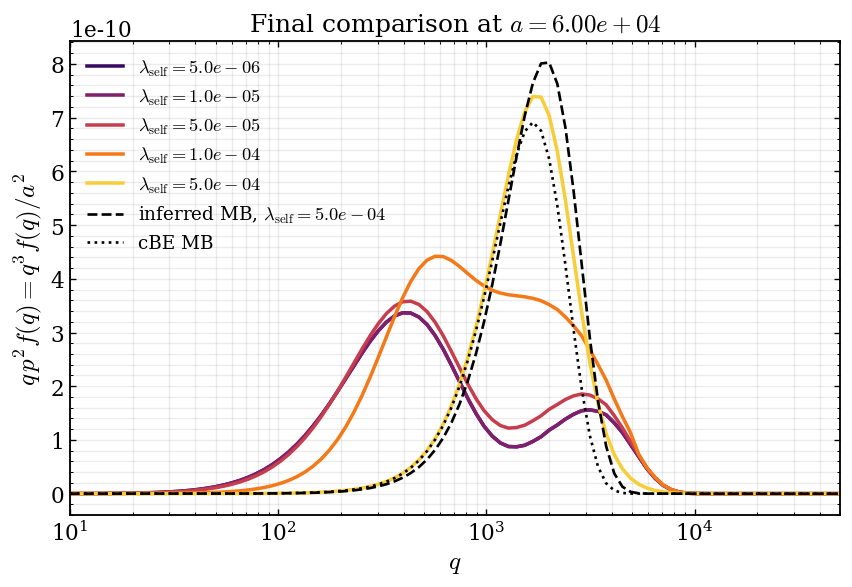

Curve diagnostics:
lambda=5.0e-06 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=3.367e-10 | positive_points=156 | finite=True
lambda=1.0e-05 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=3.367e-10 | positive_points=156 | finite=True
lambda=5.0e-05 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=3.583e-10 | positive_points=156 | finite=True
lambda=1.0e-04 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=4.420e-10 | positive_points=156 | finite=True
lambda=5.0e-04 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=7.394e-10 | positive_points=156 | finite=True

Reference largest lambda:
lambda_self = 5.000000e-04
a_final     = 6.000000e+04
T_inferred  = 6.838797e-04
n_inferred  = 7.369887e-16
log z       = 6.559316e+02

cBE:
T_cBE       = 5.220461e-04
N_cBE       = 1.364440e-01
n_cBE       = 6.316854e-16
log z_cBE   = 6.557774e+02


In [144]:
comparison_final = plot_final_lambdas_with_MB_and_cBE(
    loaded_runs,
    Ns=Ns if "Ns" in globals() else None,
    Ts=Ts if "Ts" in globals() else None,
    quantity="q_p2f",
    cmap_name="inferno",
    yscale="linear",
    xlim=(1e1, 5e4),
    line_width=1.2,
)

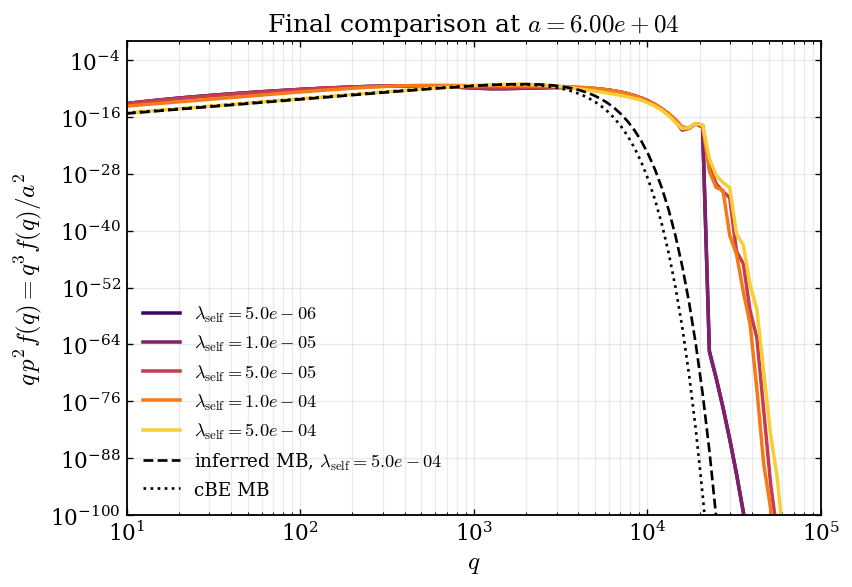

Curve diagnostics:
lambda=5.0e-06 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=3.367e-10 | positive_points=156 | finite=True
lambda=1.0e-05 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=3.367e-10 | positive_points=156 | finite=True
lambda=5.0e-05 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=3.583e-10 | positive_points=156 | finite=True
lambda=1.0e-04 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=4.420e-10 | positive_points=156 | finite=True
lambda=5.0e-04 | a_final=6.000000e+04 | y_min=0.000e+00 | y_max=7.394e-10 | positive_points=156 | finite=True

Reference largest lambda:
lambda_self = 5.000000e-04
a_final     = 6.000000e+04
T_inferred  = 6.838797e-04
n_inferred  = 7.369887e-16
log z       = 6.559316e+02

cBE:
T_cBE       = 5.220461e-04
N_cBE       = 1.364440e-01
n_cBE       = 6.316854e-16
log z_cBE   = 6.557774e+02


In [146]:
comparison_final_log = plot_final_lambdas_with_MB_and_cBE(
    loaded_runs,
    Ns=Ns if "Ns" in globals() else None,
    Ts=Ts if "Ts" in globals() else None,
    quantity="q_p2f",
    cmap_name="inferno",
    yscale="log",
    xlim=(1e1, 1e5),
    ylim=(1e-100, 1),
    line_width=1.2,
)